In [0]:
from pyspark.sql.functions import *

patients_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/delta-volume"
)

doctors_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/delta-doctor"
)

appointments_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/delta-appointment"
)

preferences_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/delta-json"
)

In [0]:
patients_df.show()
doctors_df.show()
appointments_df.show()
preferences_df.show()

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| 

In [0]:
patient_appointments_df = appointments_df.join(
    patients_df,
    on="patient_id",
    how="inner"
)

patient_appointments_df.show()

+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|patient_id|appointment_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|
+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|      P101|         A1001|     D101|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102|         A1002|     D102|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|         A1003|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104|         A1004|     D104|      2026-06-02|      Fracture| 

In [0]:
healthcare_df = patient_appointments_df.join(
    doctors_df,
    on="doctor_id",
    how="inner"
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|     city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Dr. Priya|  Neurolog

In [0]:
healthcare_df = healthcare_df.withColumn(
    "final_bill",
    when(
        col("insurance_status") == "Active",
        col("bill_amount") * 0.8
    ).otherwise(
        col("bill_amount")
    )
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|     city|consultation_fee|final_bill|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|Hyderabad|            1500|    4000.0|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Fe

In [0]:
healthcare_df = healthcare_df.withColumn(
    "appointment_month",
    month(
        to_date(
            col("appointment_date")
        )
    )
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|     city|consultation_fee|final_bill|appointment_month|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|Hyderabad|            1500|    4000.0|                6|
|     D102|      P102|         A1002|      2026-06-01|      

In [0]:
healthcare_df = healthcare_df.withColumn(
    "patient_age_group",
    when(col("age") < 30, "Young")
    .when(col("age") <= 50, "Adult")
    .otherwise("Senior")
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|     city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|Hyderabad|            1500|    4000.0|                6|       

In [0]:
healthcare_df = healthcare_df.join(
    preferences_df,
    on="patient_id",
    how="left"
)

healthcare_df.show()

+----------+---------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+------------------+----------+--------------+
|patient_id|doctor_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|     city|consultation_fee|final_bill|appointment_month|patient_age_group|preferred_hospital|     phone|         email|
+----------+---------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+---------+----------------+----------+-----------------+-----------------+------------------+----------+--------------+
|      P101|     D101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hy

In [0]:
healthcare_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: double (nullable = true)
 |-- appointment_month: integer (nullable = true)
 |-- patient_age_group: string (nullable = false)
 |-- preferred_hospital: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email: string (nullable = true)



In [0]:
from pyspark.sql.functions import *

patients_renamed = patients_df.withColumnRenamed(
    "city",
    "patient_city"
)

doctors_renamed = doctors_df.withColumnRenamed(
    "city",
    "doctor_city"
)

patient_appointments_df = appointments_df.join(
    patients_renamed,
    on="patient_id",
    how="inner"
)

healthcare_df = patient_appointments_df.join(
    doctors_renamed,
    on="doctor_id",
    how="inner"
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active

In [0]:
(
    healthcare_df.write
    .mode("overwrite")
    .format("delta")
    .save("/Volumes/hexa_databrick_7405612841012936/default/healthcare_silver")
)

In [0]:
spark.read.format("delta") \
.load("/Volumes/hexa_databrick_7405612841012936/default/healthcare_silver") \
.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active

In [0]:
from pyspark.sql.functions import *
import matplotlib.pyplot as plt

healthcare_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/healthcare_silver"
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active

In [0]:
healthcare_df.printSchema()

root
 |-- doctor_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- patient_city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)



In [0]:
print(healthcare_df.columns)

['doctor_id', 'patient_id', 'appointment_id', 'appointment_date', 'diagnosis', 'bill_amount', 'status', 'patient_name', 'patient_city', 'state', 'age', 'gender', 'insurance_status', 'doctor_name', 'department', 'doctor_city', 'consultation_fee']


In [0]:
from pyspark.sql.functions import when, col

healthcare_df = healthcare_df.withColumn(
    "final_bill",
    when(
        col("insurance_status") == "Active",
        col("bill_amount") * 0.8
    ).otherwise(
        col("bill_amount")
    )
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|    4000.0|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Banga

In [0]:
healthcare_df.printSchema()

root
 |-- doctor_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- appointment_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- patient_city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- doctor_city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)
 |-- final_bill: double (nullable = true)



In [0]:
department_df = healthcare_df.groupBy(
    "department"
).sum(
    "final_bill"
).toPandas()

department_df

,department,sum(final_bill)
0,Orthopedics,13200.0
1,Cardiology,20600.0
2,Pediatrics,1200.0
3,Dermatology,4000.0
4,Neurology,2800.0


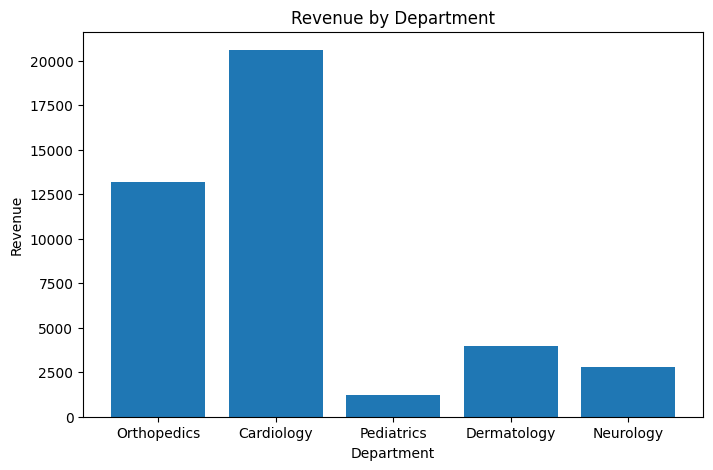

In [0]:
plt.figure(figsize=(8,5))

plt.bar(
    department_df["department"],
    department_df["sum(final_bill)"]
)

plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")

plt.show()

In [0]:
print(healthcare_df.columns)

['doctor_id', 'patient_id', 'appointment_id', 'appointment_date', 'diagnosis', 'bill_amount', 'status', 'patient_name', 'patient_city', 'state', 'age', 'gender', 'insurance_status', 'doctor_name', 'department', 'doctor_city', 'consultation_fee', 'final_bill']


In [0]:
healthcare_df.select(
    "final_bill"
).printSchema()

root
 |-- final_bill: double (nullable = true)



In [0]:
from pyspark.sql.functions import col

healthcare_df = healthcare_df.withColumn(
    "final_bill",
    col("final_bill").cast("double")
)

In [0]:
healthcare_df.select("final_bill").printSchema()

root
 |-- final_bill: double (nullable = true)



In [0]:
department_df = healthcare_df.groupBy(
    "department"
).sum(
    "final_bill"
)

department_df.show()

+-----------+---------------+
| department|sum(final_bill)|
+-----------+---------------+
|Orthopedics|        13200.0|
| Cardiology|        20600.0|
| Pediatrics|         1200.0|
|Dermatology|         4000.0|
|  Neurology|         2800.0|
+-----------+---------------+



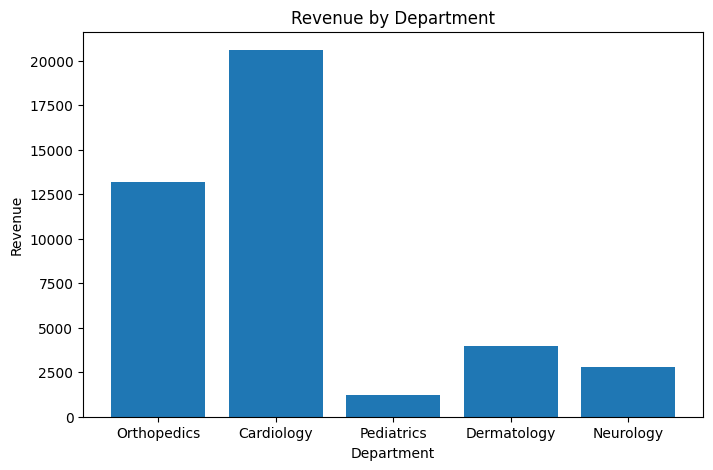

In [0]:
department_df = department_df.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    department_df["department"],
    department_df["sum(final_bill)"]
)

plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")

plt.show()

In [0]:
healthcare_df = spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/healthcare_silver"
)

healthcare_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active

In [0]:
healthcare_df.createOrReplaceTempView(
    "healthcare"
)

In [0]:
spark.sql(
    "SHOW TABLES"
).show()

+--------+----------+-----------+
|database| tableName|isTemporary|
+--------+----------+-----------+
| default|   doctors|      false|
|        |healthcare|       true|
+--------+----------+-----------+



In [0]:
spark.sql("""
SELECT *
FROM healthcare
""").show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|   Bangalore|  Karnataka| 29|Female|          Active

In [0]:
spark.sql("""
SELECT
patient_city,
COUNT(*) AS patient_count
FROM healthcare
GROUP BY patient_city
ORDER BY patient_count DESC
""").show()

+------------+-------------+
|patient_city|patient_count|
+------------+-------------+
|   Hyderabad|            3|
|       Delhi|            2|
|     Chennai|            1|
|       Kochi|            1|
|   Bangalore|            1|
|        Pune|            1|
|      Mumbai|            1|
+------------+-------------+



In [0]:
spark.sql("""
SELECT
patient_name,
insurance_status
FROM healthcare
WHERE insurance_status='Active'
""").show()

+------------+----------------+
|patient_name|insurance_status|
+------------+----------------+
|Rahul Sharma|          Active|
| Priya Reddy|          Active|
| Sneha Patel|          Active|
|  Farhan Ali|          Active|
| Arjun Verma|          Active|
|  Meera Nair|          Active|
|Rahul Sharma|          Active|
| Sneha Patel|          Active|
+------------+----------------+



In [0]:
spark.sql("""
SELECT
status,
COUNT(*) AS total_appointments
FROM healthcare
GROUP BY status
""").show()

+---------+------------------+
|   status|total_appointments|
+---------+------------------+
|  Pending|                 2|
|Cancelled|                 1|
|Completed|                 7|
+---------+------------------+



In [0]:
healthcare_df.createOrReplaceTempView(
    "healthcare"
)

In [0]:
from pyspark.sql.functions import when, col

healthcare_df = healthcare_df.withColumn(
    "final_bill",
    when(
        col("insurance_status") == "Active",
        col("bill_amount") * 0.8
    ).otherwise(
        col("bill_amount")
    )
)

In [0]:
print(healthcare_df.columns)

['doctor_id', 'patient_id', 'appointment_id', 'appointment_date', 'diagnosis', 'bill_amount', 'status', 'patient_name', 'patient_city', 'state', 'age', 'gender', 'insurance_status', 'doctor_name', 'department', 'doctor_city', 'consultation_fee', 'final_bill']


In [0]:
healthcare_df.createOrReplaceTempView(
    "healthcare"
)

In [0]:
spark.sql("""
DESCRIBE healthcare
""").show(truncate=False)

+----------------+---------+-------+
|col_name        |data_type|comment|
+----------------+---------+-------+
|doctor_id       |string   |NULL   |
|patient_id      |string   |NULL   |
|appointment_id  |string   |NULL   |
|appointment_date|date     |NULL   |
|diagnosis       |string   |NULL   |
|bill_amount     |int      |NULL   |
|status          |string   |NULL   |
|patient_name    |string   |NULL   |
|patient_city    |string   |NULL   |
|state           |string   |NULL   |
|age             |int      |NULL   |
|gender          |string   |NULL   |
|insurance_status|string   |NULL   |
|doctor_name     |string   |NULL   |
|department      |string   |NULL   |
|doctor_city     |string   |NULL   |
|consultation_fee|int      |NULL   |
|final_bill      |double   |NULL   |
+----------------+---------+-------+



In [0]:
spark.sql("""
SELECT
patient_name,
doctor_name,
final_bill
FROM healthcare
ORDER BY final_bill DESC
LIMIT 5
""").show()

+------------+-----------+----------+
|patient_name|doctor_name|final_bill|
+------------+-----------+----------+
| Sneha Patel| Dr. Suresh|    9600.0|
|  Neha Singh|  Dr. Kiran|    7000.0|
|Rahul Sharma|  Dr. Kiran|    5200.0|
| Arjun Verma| Dr. Ramesh|    4400.0|
|Rahul Sharma| Dr. Ramesh|    4000.0|
+------------+-----------+----------+



Window Functions


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
bill_window = Window.orderBy(
    col("final_bill").desc()
)

rank_df = healthcare_df.withColumn(
    "rank",
    rank().over(bill_window)
)

rank_df.select(
    "patient_name",
    "final_bill",
    "rank"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+----------+----+
|patient_name|final_bill|rank|
+------------+----------+----+
| Sneha Patel|    9600.0|   1|
|  Neha Singh|    7000.0|   2|
|Rahul Sharma|    5200.0|   3|
| Arjun Verma|    4400.0|   4|
|Rahul Sharma|    4000.0|   5|
| Sneha Patel|    3600.0|   6|
| Priya Reddy|    2800.0|   7|
|  Amit Kumar|    2000.0|   8|
|  Meera Nair|    2000.0|   8|
|  Farhan Ali|    1200.0|  10|
+------------+----------+----+



In [0]:
dense_rank_df = healthcare_df.withColumn(
    "dense_rank",
    dense_rank().over(bill_window)
)

dense_rank_df.select(
    "patient_name",
    "final_bill",
    "dense_rank"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+----------+----------+
|patient_name|final_bill|dense_rank|
+------------+----------+----------+
| Sneha Patel|    9600.0|         1|
|  Neha Singh|    7000.0|         2|
|Rahul Sharma|    5200.0|         3|
| Arjun Verma|    4400.0|         4|
|Rahul Sharma|    4000.0|         5|
| Sneha Patel|    3600.0|         6|
| Priya Reddy|    2800.0|         7|
|  Amit Kumar|    2000.0|         8|
|  Meera Nair|    2000.0|         8|
|  Farhan Ali|    1200.0|         9|
+------------+----------+----------+



In [0]:
row_df = healthcare_df.withColumn(
    "row_number",
    row_number().over(bill_window)
)

row_df.select(
    "patient_name",
    "final_bill",
    "row_number"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+----------+----------+
|patient_name|final_bill|row_number|
+------------+----------+----------+
| Sneha Patel|    9600.0|         1|
|  Neha Singh|    7000.0|         2|
|Rahul Sharma|    5200.0|         3|
| Arjun Verma|    4400.0|         4|
|Rahul Sharma|    4000.0|         5|
| Sneha Patel|    3600.0|         6|
| Priya Reddy|    2800.0|         7|
|  Amit Kumar|    2000.0|         8|
|  Meera Nair|    2000.0|         9|
|  Farhan Ali|    1200.0|        10|
+------------+----------+----------+



In [0]:
revenue_window = Window.orderBy(
    "appointment_date"
)

running_total_df = healthcare_df.withColumn(
    "running_revenue",
    sum("final_bill").over(revenue_window)
)

running_total_df.select(
    "appointment_date",
    "final_bill",
    "running_revenue"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------------+----------+---------------+
|appointment_date|final_bill|running_revenue|
+----------------+----------+---------------+
|      2026-06-01|    4000.0|         6800.0|
|      2026-06-01|    2800.0|         6800.0|
|      2026-06-02|    2000.0|        18400.0|
|      2026-06-02|    9600.0|        18400.0|
|      2026-06-03|    1200.0|        26600.0|
|      2026-06-03|    7000.0|        26600.0|
|      2026-06-04|    4400.0|        33000.0|
|      2026-06-04|    2000.0|        33000.0|
|      2026-06-05|    5200.0|        41800.0|
|      2026-06-05|    3600.0|        41800.0|
+----------------+----------+---------------+



In [0]:
top_patient_window = Window.orderBy(
    col("final_bill").desc()
)

top_patients_df = healthcare_df.withColumn(
    "row_num",
    row_number().over(top_patient_window)
)

top_patients_df.filter(
    col("row_num") <= 3
).select(
    "patient_name",
    "doctor_name",
    "final_bill"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-----------+----------+
|patient_name|doctor_name|final_bill|
+------------+-----------+----------+
| Sneha Patel| Dr. Suresh|    9600.0|
|  Neha Singh|  Dr. Kiran|    7000.0|
|Rahul Sharma|  Dr. Kiran|    5200.0|
+------------+-----------+----------+



In [0]:
doctor_revenue_df = healthcare_df.groupBy(
    "doctor_name"
).agg(
    sum("final_bill").alias("total_revenue")
)

doctor_window = Window.orderBy(
    col("total_revenue").desc()
)

doctor_rank_df = doctor_revenue_df.withColumn(
    "rank",
    rank().over(doctor_window)
)

doctor_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+----+
|doctor_name|total_revenue|rank|
+-----------+-------------+----+
| Dr. Suresh|      13200.0|   1|
|  Dr. Kiran|      12200.0|   2|
| Dr. Ramesh|       8400.0|   3|
|  Dr. Anita|       4000.0|   4|
|  Dr. Priya|       2800.0|   5|
|  Dr. Meera|       1200.0|   6|
+-----------+-------------+----+



In [0]:
doctor_patient_window = Window.partitionBy(
    "doctor_name"
).orderBy(
    col("final_bill").desc()
)

highest_patient_df = healthcare_df.withColumn(
    "row_num",
    row_number().over(doctor_patient_window)
)

highest_patient_df.filter(
    col("row_num") == 1
).select(
    "doctor_name",
    "patient_name",
    "final_bill"
).show()

+-----------+------------+----------+
|doctor_name|patient_name|final_bill|
+-----------+------------+----------+
|  Dr. Anita|  Amit Kumar|    2000.0|
|  Dr. Kiran|  Neha Singh|    7000.0|
|  Dr. Meera|  Farhan Ali|    1200.0|
|  Dr. Priya| Priya Reddy|    2800.0|
| Dr. Ramesh| Arjun Verma|    4400.0|
| Dr. Suresh| Sneha Patel|    9600.0|
+-----------+------------+----------+



In [0]:
(
    healthcare_df.write
    .mode("overwrite")
    .format("delta")
    .saveAsTable('hexa_volume')
)

In [0]:
spark.read.format("delta").load(
    "/Volumes/hexa_databrick_7405612841012936/default/healthcare_delta"
)

In [0]:
spark.sql("""
DESCRIBE HISTORY hexa_volume
""").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+-------------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                

In [0]:
spark.sql("""
DESCRIBE HISTORY hexa_volume
""").select("version").show()

+-------+
|version|
+-------+
|      1|
|      0|
+-------+

